# Coleta de Dados e Pandas

In [1]:
# Apenas para MacOS, para resolver o problema de certificado SSL
# import os
# os.environ['SSL_CERT_FILE'] = '/etc/ssl/cert.pem'
# os.environ['REQUESTS_CA_BUNDLE'] = '/etc/ssl/cert.pem'

In [2]:
# !pip install --upgrade pip
# !pip install requests
# !pip install matplotlib
# !pip install openpyxl
# !pip install --upgrade certifi
# !pip install missingno
# !pip install scikit-learn

## Importações de Bibliotecas

In [3]:
import requests
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

import missingno as msno
from scipy import stats
from sklearn.impute import KNNImputer

## 1. Carregar a Base de Dados
Lembre-se de utilizar a última base de dados exportada

In [4]:
url = "https://raw.githubusercontent.com/prof-mrafaelbatista/261_UNIESP_MBA-DADOS_data_mining_inferencia_estatistica/refs/heads/main/datasets/OnlineRetail.csv"

In [5]:
# df = pd.read_excel(url)
df = pd.read_csv(url, encoding='latin1')
# df = pd.read_csv(url)

### Renomeie todas as colunas do seu dataset para snake_case (letras minúsculas, underscores no lugar de espaços). 

In [6]:
df.columns = [c.lower().strip().replace(' ','_') for c in df.columns]
print(df.columns.tolist()) 

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


### Verifique e remova linhas duplicadas. Quantas foram removidas? 

In [7]:
antes = df.shape[0]
df = df.drop_duplicates()
print(f'Removidas: {antes - df.shape[0]}') 

Removidas: 5268


###  Se houver coluna de data, converta para datetime e extraia ao menos uma feature nova (mês, ano ou dia da semana). 

In [8]:
# df['data'] = pd.to_datetime(df['data'])
# df['mes'] = df['data'].dt.month 

### Gere a matriz de correlação das variáveis numéricas. Existe algum par com |r| > 0,8?

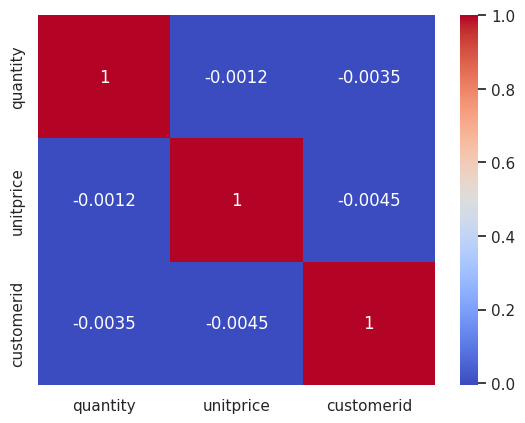

In [9]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Salve uma nova versão do DataFrame tratado como CSV ou Parquet.